# Lab 5: Transfer learning.

Thanks to their capability to learn generalizable descriptors directly from images, deep Convolutional Neural Networks (CNNs) seem the ideal solution to most pattern recognition problems. On the other hand, to learn the image representation, CNNs need huge sets of annotated samples that are unfeasible in many every-day scenarios. This is the case, for example, of Computer-Aided Diagnosis (CAD) systems for digital pathology, where additional challenges are
posed by the high variability of the cancerous tissue characteristics.
In this notebooks you are going to implement 4 different training paradigms leveraging CNNs:


1.   Training from scratch
2.   Features extractor followed by SVM
3.   Fine tuning




# Import and settings

In [151]:
import os
import cv2
import glob
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [152]:
!git clone https://github.com/frpnz/dataset-BIOSTEC2018.git
ROOTDIR_DATASET = "/content/dataset-BIOSTEC2018/crc_images"
IMAGE_SIZE = 32
NUM_CLASSES = 3
BATCH_SIZE = 32

fatal: destination path 'dataset-BIOSTEC2018' already exists and is not an empty directory.


## Utils

In [153]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")
    ax.axis("off")

# Assignment #1: create two tensorflow dataset for train and test.
Leverage the API [tf.keras.utils.image_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory).

In [154]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    ROOTDIR_DATASET + "/train",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    ROOTDIR_DATASET + "/test",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle = False
)

Found 9000 files belonging to 3 classes.
Found 4500 files belonging to 3 classes.


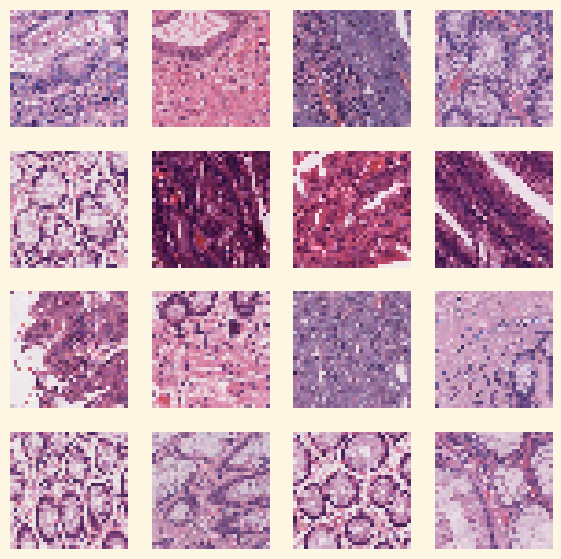

In [155]:
j = 0
fig, ax = plt.subplots(4, 4, figsize=(7, 7))
ax = ax.ravel()
for batch in train_ds.take(1):
    images = batch[0]
    labels = batch[1]
    for image, label in zip(images, labels):
        if j >= 16:
            break
        image = image.numpy().astype(np.uint8)
        ax[j].imshow(image)
        ax[j].axis("off")
        j += 1

# Assignment #2: dataset preparation
1.   Normalize images in the range [0, 1]
2.   Prepare the input pipeline via tf.data.Dataset methods



In [156]:
def process_data(image, label):
    return tf.cast(image, tf.float32) / 255., label

train_ds = train_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
# because we loaded data from directory it already shuffled and batched the data

test_ds = test_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.cache()
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Assignment #3: train a VGG16 from scratch for 50 epochs

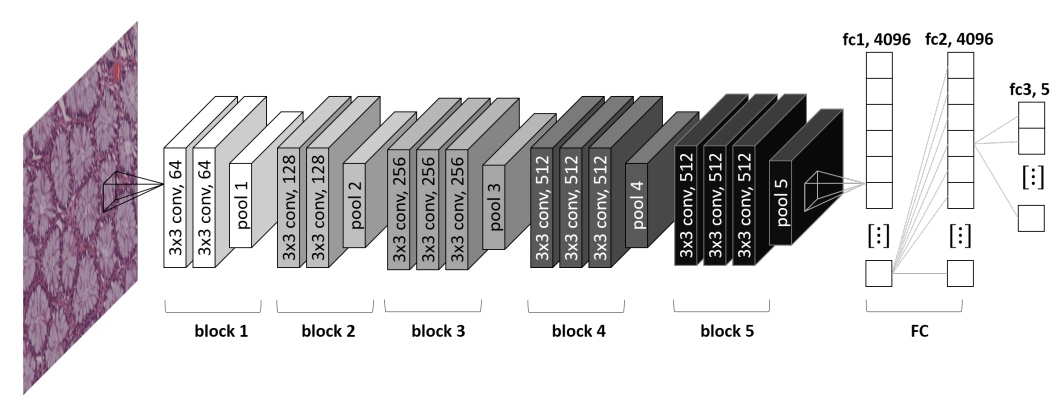

In [157]:
vgg16 = tf.keras.applications.VGG16(
    include_top=True,
    weights=None,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    classes=NUM_CLASSES
)

In [ ]:
vgg16.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
history = vgg16.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50
)

Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 53s 159ms/step - accuracy: 0.3383 - loss: 1.1040 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.3661 - loss: 1.0830 - val_accuracy: 0.3333 - val_loss: 1.0991
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.4526 - loss: 0.9452 - val_accuracy: 0.6749 - val_loss: 0.6935
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.7794 - loss: 0.4986 - val_accuracy: 0.7571 - val_loss: 0.5344
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.8406 - loss: 0.3917 - val_accuracy: 0.7278 - val_loss: 0.5507
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.8650 - loss: 0.3300 - val_accuracy: 0.7060 - val_loss: 0.8130
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.8906 - loss: 0.2748 - val_accuracy: 0.7602 - val_loss: 0.8630
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.9194 - loss: 0.2166 -

## Plot train loss and accuracy among epochs (see [History](tf.keras.callbacks.History) object)

In [ ]:
plt.style.use("Solarize_Light2")
fig, ax = plt.subplots(2, 1)

# plot_1
ax[0].plot(history.history['loss'], label='Training Loss', color='blue')
if 'val_loss' in history.history:
    ax[0].plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')

ax[0].set_title('Loss over Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='upper right')

# plot_2
ax[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
if 'val_accuracy' in history.history:
    ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')

ax[1].set_title('Accuracy over Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# Assignment #4: extract features from VGG16 pre-trained on ImageNet and then train and test a downstream SVM.

Pipeline:
1. Features extraction from the CNN
2. PCA
3. SVM training and test

N.B. Do not shuffle train and test in order to extract labels in the correct order.

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
     ROOTDIR_DATASET + "/train",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)


test_ds = tf.keras.preprocessing.image_dataset_from_directory(
     ROOTDIR_DATASET + "/test",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle = False
)

In [ ]:
def process_data(image, label):
    image = tf.cast(image, tf.float32)
    return tf.keras.applications.vgg16.preprocess_input(image), label

train_ds = train_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

test_ds = test_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.cache()
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
vgg16 = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    classes=NUM_CLASSES
)

In [ ]:
feature_extractor = tf.keras.Sequential([
    vgg16,
    tf.keras.layers.GlobalAveragePooling2D()
])

In [ ]:
train_features = feature_extractor.predict(train_ds)
test_features = feature_extractor.predict(test_ds)

In [ ]:
# labels_train = np.concatenate([np.argmax(y, axis=1) for _, y in train_ds], axis=0)
# labels_test = np.concatenate([np.argmax(y, axis=1) for _, y in test_ds], axis=0)

train_labels = np.concatenate([y for x, y in train_ds], axis=0)
test_labels = np.concatenate([y for x, y in test_ds], axis=0)

In [ ]:
pca = PCA(n_components=0.95, random_state=42)

In [ ]:
train_features_pca = pca.fit_transform(train_features)
test_features_pca = pca.transform(test_features)

In [ ]:
svm_classifier = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
    )
svm_classifier.fit(train_features_pca, train_labels)

In [ ]:
predictions = svm_classifier.predict(test_features_pca)

In [ ]:
cm = confusion_matrix(test_labels, predictions)
my_class_labels = ['AC', 'AD','H']
fig, ax = plt.subplots(figsize=(7, 7))
seaborn_cm(
    cm=cm,
    ax=ax,
    tick_labels=my_class_labels,
    fontsize=14,
    title="SVM Confusion Matrix"
)
plt.show()


from sklearn.metrics import classification_report, accuracy_score
accuracy = accuracy_score(test_labels, predictions)
print(f"\nSVM Test Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(test_labels, predictions))


# Assignment #5: Fine tune the VGG16 pre-trained on ImageNet.

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    ROOTDIR_DATASET + "/train",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
     ROOTDIR_DATASET + "/test",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle = False
)

In [ ]:
def process_data(image, label):
    image = tf.cast(image, tf.float32)
    return  tf.keras.applications.vgg16.preprocess_input(image), label

train_ds = train_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

test_ds = test_ds.map(process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.cache()
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    classes=NUM_CLASSES
)

In [ ]:
base_model.trainable = False # Freeze the entire base model

In [ ]:
inputs = tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds
)

In [ ]:
plt.style.use("Solarize_Light2")
fig, ax = plt.subplots(2, 1)

# plot_1
ax[0].plot(history.history['loss'], label='Training Loss', color='blue')
if 'val_loss' in history.history:
    ax[0].plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')

ax[0].set_title('Loss over Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='upper right')

# plot_2
ax[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
if 'val_accuracy' in history.history:
    ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')

ax[1].set_title('Accuracy over Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
base_model.trainable = True # Unfreeze the base model

for layer in base_model.layers[:15]:
    layer.trainable = False

for i, layer in enumerate(base_model.layers):
    print(f"Layer {i} | {layer.name} | Trainable: {layer.trainable}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds
)

In [ ]:
plt.style.use("Solarize_Light2")
fig, ax = plt.subplots(2, 1)

# plot_1
ax[0].plot(history_finetune.history['loss'], label='Training Loss', color='blue')
if 'val_loss' in history_finetune.history:
    ax[0].plot(history_finetune.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')

ax[0].set_title('Loss over Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='upper right')

# plot_2
ax[1].plot(history_finetune.history['accuracy'], label='Training Accuracy', color='blue')
if 'val_accuracy' in history_finetune.history:
    ax[1].plot(history_finetune.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--')

ax[1].set_title('Accuracy over Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()